<h1 style="color: orange; font-size: 40px; font-weight: bold;">
LAB 12
</h1>

<h2 style="color: green; font-size: 35px; font-weight: bold;">
Deep & Convolutional Neural Network
</h2>

<h1 style="color: blue; font-size: 25px; font-weight: bold;">
12.1: Deep Neural Network
</h1>

**MNIST with Keras**

The goal of exercise 12 is to use deep neural network models, implemented in the Keras python package, to recognize and distinguish between the ten handwritten digits (0-9).

The MNIST dataset comprises 70000 handwritten digits, each of which comes in a square image, divided into a $28\times28$ pixel grid. Every pixel can take on 256 gradation of the gray color. Since there are  categories in the problem, corresponding to the ten digits, this problem represents a generic classification task.

In [45]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
seed=0
np.random.seed(seed)
tf.random.set_seed(seed)

In [46]:
img_rows, img_cols = 28, 28

num_classes = 10

(X_train, Y_train), (X_test, Y_test) = mnist.load_data()
print("X_train shape: ", X_train.shape)
print("Y_train shape: ", Y_train.shape)

X_train shape:  (60000, 28, 28)
Y_train shape:  (60000,)


One hot representation: The task was submitted to **one hot encoding**, which consists in generating an output vector of shape 10 filled with zeros, and only one integer value (1) is assigned in the index corresponding to the relative handwritten number.

The one hot encoding allows to use the categorical crossentropy loss function, which is defined as:
$$
L(y, \hat{y})=-\sum_{i=1}^{N_c}y_i\log{\hat{y}_i}.
$$

an example of a data point with label 4


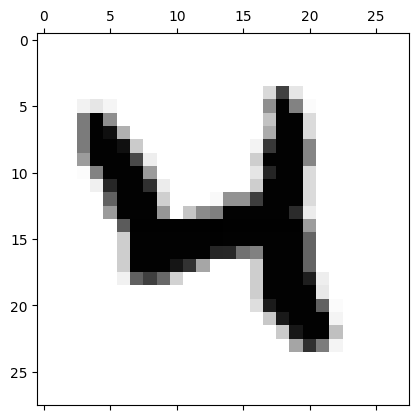

... and with label [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.] after to_categorical

X_train shape: (60000, 784)
X_test shape: (10000, 784)
Y_train shape: (60000, 10)


In [47]:
X_train = X_train.reshape(X_train.shape[0], img_rows*img_cols)
X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

X_train /= 255
X_test /= 255

print('an example of a data point with label', Y_train[20])
# matshow: display a matrix in a new figure window
plt.matshow(X_train[20,:].reshape(28,28),cmap='binary')
plt.show()

# convert class vectors to binary class matrices, e.g. for use with categorical_crossentropy
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)
print('... and with label', Y_train[20], 'after to_categorical')
print()
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Y_train shape:', Y_train.shape)

Define a function that creates our Deep Neural Network model, taking the optimizer as an input parameter.

Dropout has also been included to regularize the training process. During training, 50% of the neurons in the preceding layer are randomly deactivated at each iteration. This technique reduces overfitting by preventing the network from relying on specific neurons. ReLu activation functions have been included, to mitigate vanishing gradient.

In [48]:
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout
from keras.optimizers import SGD, Adam, Adagrad

def create_DNN(optimi):
    model = Sequential()
    model.add(Input(shape=(img_rows*img_cols,)))

    model.add(Dense(400, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(loss=keras.losses.categorical_crossentropy,
                   optimizer=optimi,
                   metrics=['acc'])

    return model

def fit(model, batch_size, epochs):
    return model.fit(X_train, Y_train,
                        batch_size=batch_size, epochs=epochs,
                        shuffle=True, verbose=1,
                        validation_data=(X_test, Y_test))

def print_performance(model, history):
    score = model.evaluate(X_test, Y_test, verbose=1)

    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.ylabel("Model accuracy")
    plt.xlabel("Epoch")
    plt.legend(['train', 'test'], loc='best')
    plt.show()

    # summarize history for loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.ylabel('model loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='best')
    plt.show()

    print()
    print("Test loss: ", score[0])
    print("Test accuracy: ", score[1])

def print_predictions(pred, y_test):
    plt.figure(figsize=(15, 15))
    for i in range(10):
        ax = plt.subplot(2, 10, i+1)
        plt.imshow(X_test[i, :, :, 0], cmap='gray')
        plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(y_test[i]), np.argmax(pred[i])))
        plt.axis('off')
    plt.show()

We now compare the performance of the model using different optimizers. In particular, we test the SGD, Adam, and Adagrad optimizers. In each case, a batch size of 32 and 10 epochs are used. SGD updates the parameters using the gradient of the loss function computed on each batch, with a fixed learning rate. Adagrad improves this approach by adapting the learning rate for each parameter according to the past gradients, reducing the learning rate for frequently updated parameters. Adam combines the advantages of momentum and adaptive learning rates, using both the first and second moments of the gradients to achieve faster and more stable convergence.

# SGD

In [49]:
batch_size = 32
epochs = 10

model_DNN = create_DNN(SGD())
history = fit(model_DNN, batch_size, epochs)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 879us/step - acc: 0.6354 - loss: 1.1799 - val_acc: 0.9148 - val_loss: 0.3140
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 845us/step - acc: 0.8827 - loss: 0.4088 - val_acc: 0.9328 - val_loss: 0.2368
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 793us/step - acc: 0.9084 - loss: 0.3229 - val_acc: 0.9429 - val_loss: 0.1985
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 798us/step - acc: 0.9253 - loss: 0.2713 - val_acc: 0.9488 - val_loss: 0.1725
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - acc: 0.9327 - loss: 0.2387 - val_acc: 0.9545 - val_loss: 0.1533
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - acc: 0.9412 - loss: 0.2139 - val_acc: 0.9565 - val_loss: 0.1405
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 832us/step - acc: 0.9450 - loss: 0.1932 - val_acc: 0.9598 - val_loss: 0.1305
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 830us/step - acc: 0.9488 - loss: 0.1811 - val_acc: 0.9613 - val_loss: 0.1217
Epoch 9/10
1875/1875 ━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - acc: 0.9590 - loss: 0.1273


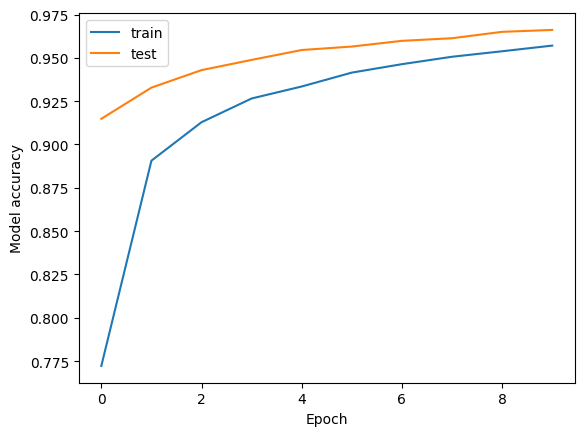

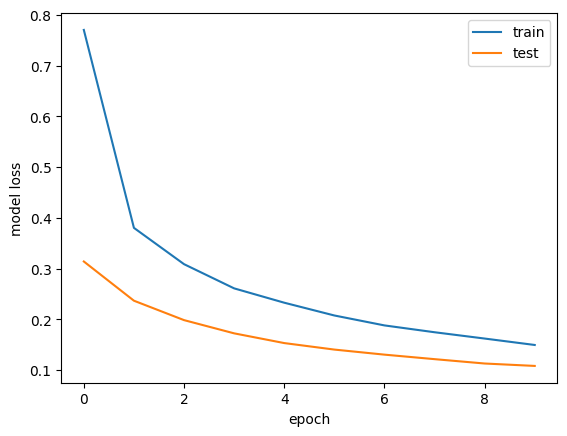


Test loss:  0.10831739753484726
Test accuracy:  0.9660999774932861


In [50]:
print_performance(model_DNN, history)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step


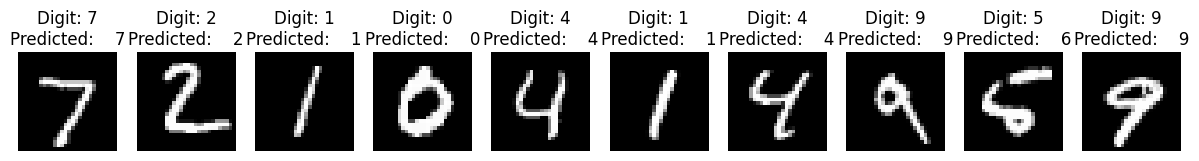

In [51]:
predictions = model_DNN.predict(X_test)

X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)

print_predictions(predictions, Y_test)

# Adagrad

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.4442 - loss: 1.7184 - val_acc: 0.8565 - val_loss: 0.6577
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.7767 - loss: 0.7831 - val_acc: 0.8867 - val_loss: 0.4676
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.8223 - loss: 0.6154 - val_acc: 0.9007 - val_loss: 0.3978
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.8435 - loss: 0.5405 - val_acc: 0.9094 - val_loss: 0.3585
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.8601 - loss: 0.4923 - val_acc: 0.9142 - val_loss: 0.3326
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.8674 - loss: 0.4641 - val_acc: 0.9168 - val_loss: 0.3143
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.8755 - loss: 0.4370 - val_acc: 0.9205 - val_loss: 0.2991
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.8848 - loss: 0.4183 - val_acc: 0.9234 - val_loss: 0.2871
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━

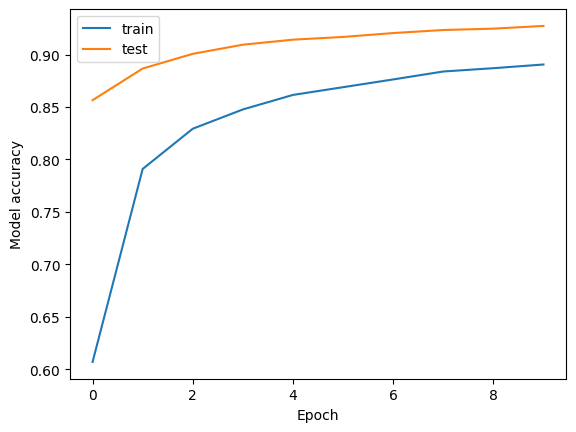

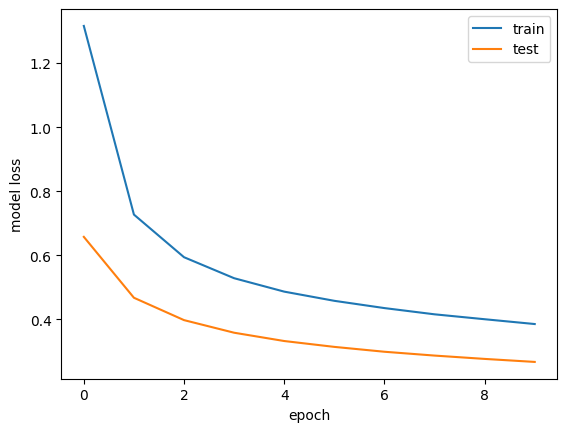


Test loss:  0.2673458158969879
Test accuracy:  0.927299976348877

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step


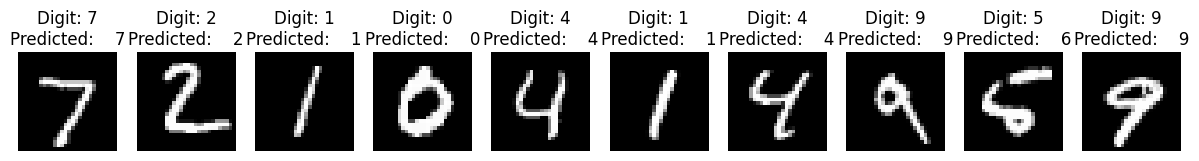

In [52]:
model_DNN = create_DNN(Adagrad())

X_train = X_train.reshape(X_train.shape[0], img_rows*img_cols)
X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)
history = fit(model_DNN, batch_size, epochs)

print_performance(model_DNN, history)
print()

predictions = model_DNN.predict(X_test)

X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
print_predictions(predictions, Y_test)

# Adam

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.8571 - loss: 0.4704 - val_acc: 0.9643 - val_loss: 0.1173
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.9611 - loss: 0.1403 - val_acc: 0.9715 - val_loss: 0.0881
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.9711 - loss: 0.0998 - val_acc: 0.9697 - val_loss: 0.1071
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.9784 - loss: 0.0740 - val_acc: 0.9758 - val_loss: 0.0902
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.9825 - loss: 0.0611 - val_acc: 0.9779 - val_loss: 0.0860
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.9849 - loss: 0.0497 - val_acc: 0.9771 - val_loss: 0.0960
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.9872 - loss: 0.0401 - val_acc: 0.9790 - val_loss: 0.0904
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.9892 - loss: 0.0352 - val_acc: 0.9780 - val_loss: 0.0881
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━

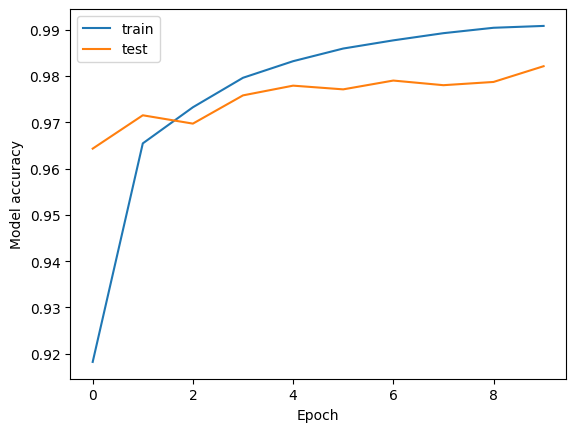

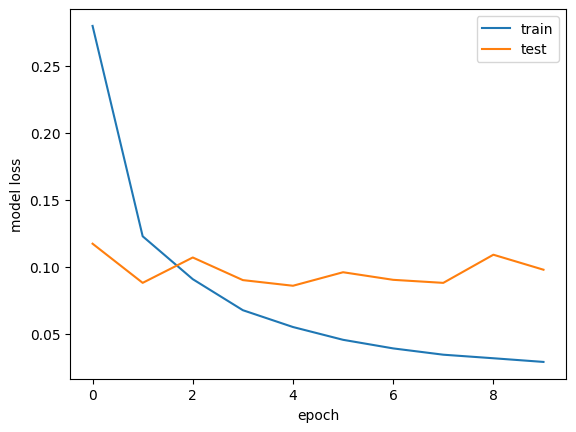


Test loss:  0.09792330116033554
Test accuracy:  0.9821000099182129

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step


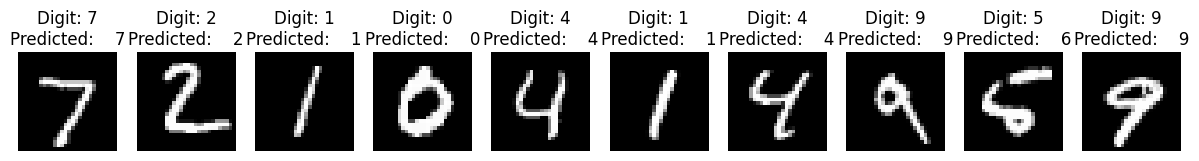

In [53]:
model_DNN = create_DNN(Adam())

X_train = X_train.reshape(X_train.shape[0], img_rows*img_cols)
X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)

history = fit(model_DNN, batch_size, epochs)

print_performance(model_DNN, history)
print()

predictions = model_DNN.predict(X_test)

X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)

print_predictions(predictions, Y_test)

<h1 style="color: blue; font-size: 25px; font-weight: bold;">
12.2: Convolutional Neural Network
</h1>

In this section, the same classification task as before is tackled using a convolutional neural network (CNN).

A CNN architecture has the following properties:
- Convolutional layers: Filters (kernels) slide locally over the input by making convolution operations (matrix) to capture local patterns (edges, shapes, textures) and relevant parameters, reducing dimensionality.
- Pooling layers (e.g. MaxPooling), which reduce dimensionality of the feature map while keeping relevant information.
- Fully connected layers: after convolution and pooling steges, the compressed data is flattened and submitted to a standard MLP, with a final output layer of dimension 10 (classification).

The main advantage of using CNN is that they exploit spatial feature, so that they work better with images.

In [54]:
from keras.layers import Flatten, Conv2D, MaxPooling2D

if keras.backend.image_data_format() == 'channels_first':
    X_train = X_train.reshape(X_train.shape[0], 1, img_rows, img_cols)
    X_test = X_test.reshape(X_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    X_train = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
    X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)
print()
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

X_train shape: (60000, 28, 28, 1)
Y_train shape: (60000, 10)

60000 train samples
10000 test samples


The CNN used for this task is made up of two convolutional layers, containing both 20 filters. The first layer uses $5\times5$ kernels, while the second uses $4\times4$ kernels. The first convolutional layer is used to extract more general features, while the second captures local correlations. These layers are followed by a MaxPooling layer.

After the flattening layer, a fully connected layer with 20 neurons is added, followed by the final output layer with 10 neurons and a softmax classifier. A dropout rate of 50% is applied to the first Dense layer.
The model is then trained again using a batch size of 32 and 10 epochs, in order to compare its performance with the previously used DNN.

In [55]:
def create_CNN():
    model = Sequential()
    model.add(Conv2D(20, kernel_size=(5,5),
                     activation='relu',
                     input_shape=input_shape))
    model.add(Conv2D(20, kernel_size=(4,4),
                     activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Flatten())
    model.add(Dense(20, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(loss=keras.losses.categorical_crossentropy, optimizer=SGD(), metrics=['acc'])
    return model

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.4391 - loss: 1.5455 - val_acc: 0.9234 - val_loss: 0.3743
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - acc: 0.7095 - loss: 0.7824 - val_acc: 0.9568 - val_loss: 0.1732
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.7868 - loss: 0.5977 - val_acc: 0.9636 - val_loss: 0.1283
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.8333 - loss: 0.4976 - val_acc: 0.9713 - val_loss: 0.1082
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - acc: 0.8408 - loss: 0.4629 - val_acc: 0.9726 - val_loss: 0.0976
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.8494 - loss: 0.4327 - val_acc: 0.9765 - val_loss: 0.0857
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.8615 - loss: 0.3995 - val_acc: 0.9785 - val_loss: 0.0754
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.8663 - loss: 0.3810 - val_acc: 0.9810 - val_loss: 0.0689
Epoch 9/10
1875/1875 ━━━━━━━━━━━

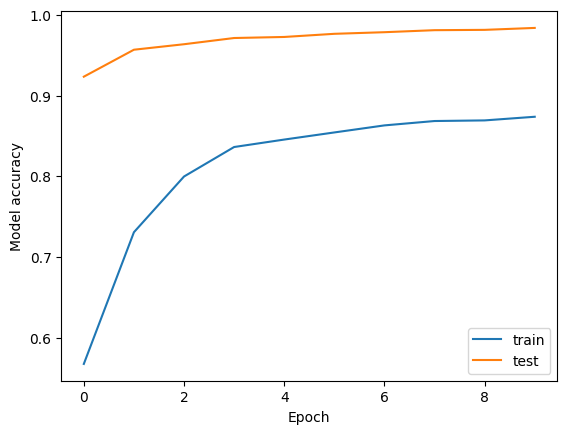

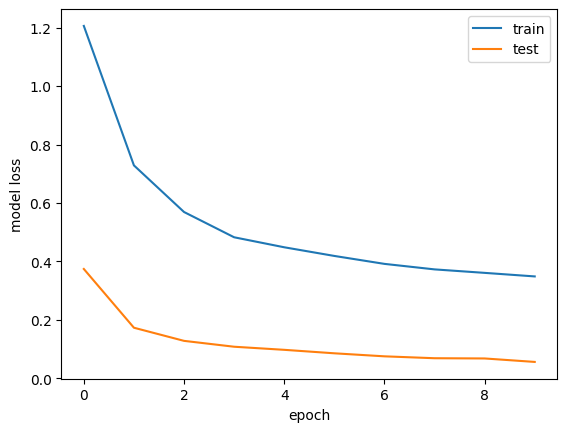


Test loss:  0.05623067542910576
Test accuracy:  0.9837999939918518

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


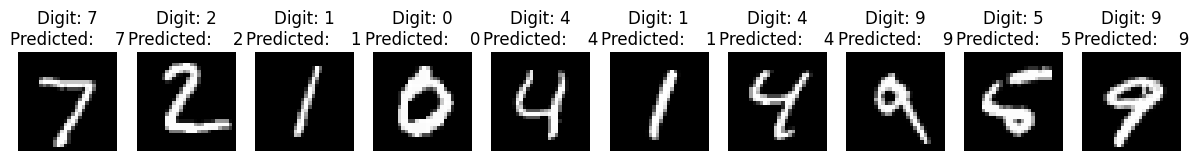

In [56]:
epochs = 10

model_cnn = create_CNN()

history = fit(model_cnn, batch_size, epochs)

print_performance(model_cnn, history)
print()

predictions = model_cnn.predict(X_test)

X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)

print_predictions(predictions, Y_test)

# Conclusion

The final comparison shows that both models (DNN and CNN) achieve good performance; however, the CNN provides better results, reaching an accuracy of 0.984, which is higher than the values obtained with the DNN (SGD accuracy: 0.966; Adagrad accuracy: 0.927; Adam accuracy: 0.982). In particular, the DNN models trained with SGD and Adagrad achieve lower performances, while the most meaningful comparison is with the Adam optimizer, which provides a result closer to the CNN.

<h1 style="color: blue; font-size: 25px; font-weight: bold;">
12.3: Generalization
</h1>

In this section the ability of the CNN and the DNN to generalize on unseen data has been tested by making it predict mine handwritten digits.

Since these images ar in principle very different from the MNIST ones, the performance is poorer than on the validation dataset.

In [57]:
from PIL import Image
import os

def print_custom_predictions(prediction, x_custom, filename):
    plt.figure(figsize=(15, 15))

    n = len(x_custom)

    for i in range(n):
        ax = plt.subplot(2, 10, i+1)
        plt.imshow(x_custom[i, :, :, 0], cmap='grey')
        plt.title("{}\nPredicted: {}".format(filename[i], np.argmax(prediction[i])))
        plt.axis('off')

    plt.show()

def count_correct(filename, prediction):
    count = 0
    for i in range(len(filename)):
        true_label = int(filename[i].split(".")[0])
        predicted_label = np.argmax(prediction[i])
        if predicted_label == true_label:
            count += 1
    print("Predicted ", count, " correct label out of ", len(filename))
    print("Accuracy: ", count / len(filename))

images = []
filenames = []

for filename in os.listdir("./IMAGES"):
    if filename.endswith(".png"):
        digit_filename = os.path.join("./IMAGES", filename)
        digit_in = Image.open(digit_filename).convert('L')
        xdim, ydim = digit_in.size

        #print("Image size: ", xdim, "x", ydim)
        pix = digit_in.load()
        data = np.zeros((xdim, ydim))
        for j in range(ydim):
            for i in range(xdim):
                data[i, j] = pix[j, i]
        data /= 255

        images.append(data)
        filenames.append(filename)

X_custom = np.array(images)
print(X_custom.shape)
print(model_cnn.input_shape)

X_custom = X_custom.reshape(X_custom.shape[0], xdim, ydim, 1)
print(X_custom.shape)

(10, 28, 28)
(None, 28, 28, 1)
(10, 28, 28, 1)


# CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


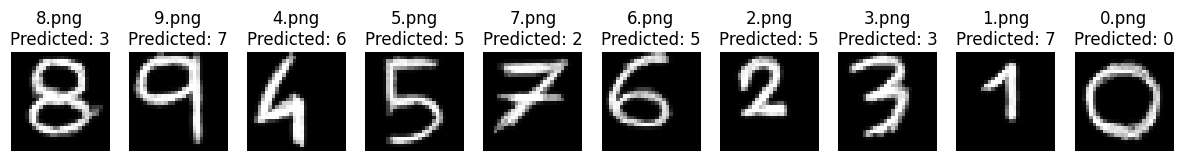

Predicted  3  correct label out of  10
Accuracy:  0.3


In [58]:
predictions = model_cnn.predict(X_custom)
print_custom_predictions(predictions, X_custom, filenames)
count_correct(filenames, predictions)

# DNN Adam

(10, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


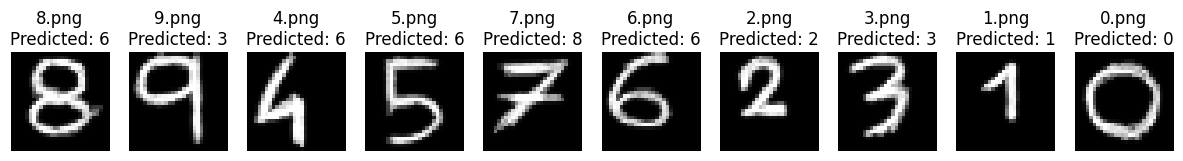

Predicted  5  correct label out of  10
Accuracy:  0.5


In [59]:
X_custom = X_custom.reshape(X_custom.shape[0], xdim*ydim)
print(X_custom.shape)
predictions = model_DNN.predict(X_custom)
X_custom = X_custom.reshape(X_custom.shape[0], xdim, ydim, 1)
print_custom_predictions(predictions, X_custom, filenames)
count_correct(filenames, predictions)

<h1 style="color: green; font-size: 25px; font-weight: bold;">
12.3: Conclusions
</h1>

Finally, we observe that the generalization capability on images slightly different from those in the MNIST dataset is not optimal. A possible explanation is that the model was trained for a limited number of epochs, which may have prevented it from learning sufficiently general features.